# Brill POS Tagger — Universal Dependencies
### Multi-Language Training, Benchmarks, ONNX Export & Full Analysis

**Pipeline:**
1. Load UD treebanks from HuggingFace (`universal-dependencies/universal_dependencies`)
2. Train **DefaultTagger → AffixTagger (suffix) → AffixTagger (prefix) → UnigramTagger → BigramTagger → TrigramTagger → BrillTagger** chain per treebank
3. Evaluate: per-tag P/R/F1, OOV accuracy, confusion matrix, cross-lingual comparison
4. Character n-gram & morphological analysis of the treebanks
5. Learning curves (training size vs. accuracy)
6. MLflow tracking + HuggingFace Hub upload

## 1 · Install Dependencies

In [23]:
!pip install datasets nltk joblib mlflow scikit-learn huggingface_hub onnx onnxruntime onnxscript numpy matplotlib tqdm

import nltk
for pkg in ["punkt", "averaged_perceptron_tagger"]:
    nltk.download(pkg, quiet=True)
print("All dependencies installed.")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All dependencies installed.


## 2 · Configuration

In [24]:
import os

def _env(key, default=""):  return os.environ.get(key, default)
def _flag(key, default=False):
    return os.environ.get(key, str(default)).lower() in ("1", "true", "yes")
def _list(key, default):
    v = os.environ.get(key, default)
    return [x.strip() for x in v.split(",") if x.strip()]

# ── Dataset ───────────────────────────────────────────────────────────────────
# Each treebank is a config name in universal-dependencies/universal_dependencies
# Examples: en_ewt, pt_bosque, fr_gsd, de_gsd, es_gsd, it_isdt, zh_gsd, ar_padt
# Special key: "all-{lang}" to use all subsets of same language. Examples: all, all-en, all-pt

TREEBANKS         = _list("TREEBANKS", "en_ewt,pt_bosque,fr_gsd,de_gsd,es_gsd")

HF_UD_REPO        = _env("HF_UD_REPO", "commul/universal_dependencies")
UPOS_COLUMN       = _env("UPOS_COLUMN",  "upos")
TOKENS_COLUMN     = _env("TOKENS_COLUMN", "tokens")
# 'upos' = 17 universal tags; 'xpos' = language-specific (use 'upos' for cross-lingual)
TAG_SET           = _env("TAG_SET", "upos")

# ── Training ──────────────────────────────────────────────────────────────────
BRILL_MAX_RULES   = int  (_env("BRILL_MAX_RULES",  "200"))
BRILL_MIN_SCORE   = int  (_env("BRILL_MIN_SCORE",  "3"))
SUFFIX_LEN        = int  (_env("SUFFIX_LEN",        "3"))
AFFIX_LEN         = int  (_env("AFFIX_LEN",         "3"))
LOWERCASE         = _flag("LOWERCASE",              False)
N_JOBS            = int  (_env("N_JOBS",            "-1"))
RANDOM_SEED       = int  (_env("RANDOM_SEED",       "42"))

# ── N-gram analysis ───────────────────────────────────────────────────────────
NGRAM_MAX_N       = int  (_env("NGRAM_MAX_N",       "4"))
NGRAM_TOP_K       = int  (_env("NGRAM_TOP_K",       "20"))

# ── Benchmarks ────────────────────────────────────────────────────────────────
BENCH_SENTS       = int  (_env("BENCH_SENTS",       "500"))
LEARNING_CURVE_FRACS = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

# ── ONNX ─────────────────────────────────────────────────────────────────────
ONNX_QUANTIZE     = _flag("ONNX_QUANTIZE",          False)

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR        = _env("OUTPUT_DIR", "./pos_tagger_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── MLflow ────────────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = _env("MLFLOW_TRACKING_URI", f"{OUTPUT_DIR}/mlruns")
MLFLOW_EXPERIMENT   = _env("MLFLOW_EXPERIMENT",   "brill_pos_tagger")

# ── HuggingFace ───────────────────────────────────────────────────────────────
HF_TOKEN          = _env("HF_TOKEN", "")
HF_UPLOAD         = _flag("HF_UPLOAD", False)
HF_UPLOAD_REPO    = _env("HF_UPLOAD_REPO", "")

print("Configuration:")
for k, v in [
    ("TREEBANKS",       TREEBANKS),
    ("HF_UD_REPO",      HF_UD_REPO),
    ("TAG_SET",         TAG_SET),
    ("BRILL_MAX_RULES", BRILL_MAX_RULES),
    ("BRILL_MIN_SCORE", BRILL_MIN_SCORE),
    ("SUFFIX_LEN",      SUFFIX_LEN),
    ("LOWERCASE",       LOWERCASE),
    ("OUTPUT_DIR",      OUTPUT_DIR),
    ("ONNX_QUANTIZE",   ONNX_QUANTIZE),
]:
    print(f"  {k:<22} = {v}")

Configuration:
  TREEBANKS              = ['en_ewt', 'pt_bosque', 'fr_gsd', 'de_gsd', 'es_gsd']
  HF_UD_REPO             = commul/universal_dependencies
  TAG_SET                = upos
  BRILL_MAX_RULES        = 200
  BRILL_MIN_SCORE        = 3
  SUFFIX_LEN             = 3
  LOWERCASE              = False
  OUTPUT_DIR             = ./pos_tagger_output
  ONNX_QUANTIZE          = False


## 3 · Universal POS Tag Inventory

In [25]:
UPOS_TAGS = [
    "ADJ", "ADP", "ADV", "AUX", "CCONJ",
    "DET", "INTJ", "NOUN", "NUM", "PART",
    "PRON", "PROPN", "PUNCT", "SCONJ", "SYM",
    "VERB", "X",
]
UPOS_DESCRIPTIONS = {
    "ADJ":"Adjective",   "ADP":"Adposition",  "ADV":"Adverb",
    "AUX":"Auxiliary",   "CCONJ":"Coord Conj","DET":"Determiner",
    "INTJ":"Interjection","NOUN":"Noun",       "NUM":"Numeral",
    "PART":"Particle",   "PRON":"Pronoun",     "PROPN":"Proper Noun",
    "PUNCT":"Punctuation","SCONJ":"Subord Conj","SYM":"Symbol",
    "VERB":"Verb",        "X":"Other",
}
TAG2ID = {t: i for i, t in enumerate(UPOS_TAGS)}
TAG2ID["_"] = len(UPOS_TAGS)
ID2TAG = {v: k for k, v in TAG2ID.items()}
UNK_TAG_ID = TAG2ID["X"]
print(f"{len(UPOS_TAGS)} UPOS tags:", UPOS_TAGS)


special = [t for t in TREEBANKS if t.startswith("all")]
if special:
    from datasets import get_dataset_config_names
    ALL_TREEBANKS = get_dataset_config_names(HF_UD_REPO)
    TREEBANKS = [t for t in TREEBANKS if t not in special]
    for t in special:
        lang = t.split("-", 1)[1]
        TREEBANKS += [t for t in ALL_TREEBANKS if t.startswith(lang)]
print(f"{len(TREEBANKS)} treebanks:", TREEBANKS)

17 UPOS tags: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']
5 treebanks: ['en_ewt', 'pt_bosque', 'fr_gsd', 'de_gsd', 'es_gsd']


## 4 · Load UD Treebanks

In [26]:
import random
from datasets import load_dataset

def load_treebank(treebank_name):
    print(f"  Loading {treebank_name} ...", end=" ")
    kw = {"name": treebank_name}
    if HF_TOKEN:
        kw["token"] = HF_TOKEN
    try:
        ds = load_dataset(HF_UD_REPO, **kw)
    except Exception as e:
        print(f"FAILED: {e}")
        return None, None

    def parse_split(split_name):
        if split_name not in ds:
            return []
        sents = []
        for row in ds[split_name]:
            toks = row.get(TOKENS_COLUMN, [])
            tags = row.get(TAG_SET, row.get(UPOS_COLUMN, []))
            if not toks or not tags or len(toks) != len(tags):
                continue
            if LOWERCASE:
                toks = [t.lower() for t in toks]
            if tags and isinstance(tags[0], int):
                tags = [ID2TAG.get(u, "X") for u in tags]
            sents.append(list(zip(toks, tags)))
        return sents

    train = parse_split("train")
    test  = parse_split("test") or parse_split("validation")
    print(f"train={len(train):,}  test={len(test):,}")
    return train, test


treebank_data = {}
print("Loading treebanks:")
for tb in TREEBANKS:
    train, test = load_treebank(tb)
    if train:
        treebank_data[tb] = {"train": train, "test": test}

print(f"\nLoaded: {list(treebank_data.keys())}")

Loading treebanks:
  Loading en_ewt ... train=12,544  test=2,077
  Loading pt_bosque ... train=7,018  test=1,167
  Loading fr_gsd ... train=14,450  test=416
  Loading de_gsd ... train=13,813  test=977
  Loading es_gsd ... train=14,187  test=427

Loaded: ['en_ewt', 'pt_bosque', 'fr_gsd', 'de_gsd', 'es_gsd']


## 5 · Dataset Statistics

In [27]:
import numpy as np
from collections import Counter
import pandas as pd

dataset_stats = {}
for tb, data in treebank_data.items():
    all_sents  = data["train"] + data["test"]
    all_tokens = [tok for s in all_sents for tok, _ in s]
    all_tags   = [tag for s in all_sents for _, tag in s]
    sent_lens  = [len(s) for s in all_sents]
    dataset_stats[tb] = {
        "n_train":    len(data["train"]),
        "n_test":     len(data["test"]),
        "n_tokens":   len(all_tokens),
        "vocab_size": len(set(t.lower() for t in all_tokens)),
        "tag_dist":   Counter(all_tags),
        "sent_lens":  sent_lens,
        "unique_tags":sorted(set(all_tags)),
    }

print(f"{'Treebank':<14} | {'Train':>7} | {'Test':>6} | {'Tokens':>9} | {'Vocab':>7} | {'Tags':>5} | {'AvgLen':>7}")
print("-" * 68)
for tb, s in dataset_stats.items():
    print(f"{tb:<14} | {s['n_train']:>7,} | {s['n_test']:>6,} | "
          f"{s['n_tokens']:>9,} | {s['vocab_size']:>7,} | "
          f"{len(s['unique_tags']):>5} | {np.mean(s['sent_lens']):>6.1f}")

Treebank       |   Train |   Test |    Tokens |   Vocab |  Tags |  AvgLen
--------------------------------------------------------------------
en_ewt         |  12,544 |  2,077 |   229,671 |  18,127 |    17 |   15.7
pt_bosque      |   7,018 |  1,167 |   199,380 |  23,711 |    17 |   24.4
fr_gsd         |  14,450 |    416 |   364,665 |  40,214 |    16 |   24.5
de_gsd         |  13,813 |    977 |   280,276 |  49,413 |    17 |   19.0
es_gsd         |  14,187 |    427 |   394,446 |  42,955 |    17 |   27.0


## 6 · Train Brill POS Taggers

In [28]:
import joblib
from nltk.tag import (
    DefaultTagger, UnigramTagger, BigramTagger, TrigramTagger,
    AffixTagger, brill, brill_trainer,
)
from joblib import Parallel, delayed


def train_tagger(tb_name, train_sents, test_sents):
    cache = os.path.join(OUTPUT_DIR, f"{tb_name}_brill_pos.pkl")
    if os.path.exists(cache):
        tagger = joblib.load(cache)
        print(f"[{tb_name}] cached  rules={len(tagger.rules())}")
    else:
        print(f"[{tb_name}] training ... ({len(train_sents):,} sents)")
        default = DefaultTagger("NOUN")
        suffix  = AffixTagger(train_sents, affix_length=-SUFFIX_LEN, backoff=default)
        prefix  = AffixTagger(train_sents, affix_length= AFFIX_LEN,  backoff=suffix)
        uni     = UnigramTagger (train_sents, backoff=prefix)
        bi      = BigramTagger  (train_sents, backoff=uni)
        tri     = TrigramTagger (train_sents, backoff=bi)
        trainer = brill_trainer.BrillTaggerTrainer(
            initial_tagger=tri, templates=brill.fntbl37()
        )
        tagger = trainer.train(train_sents, max_rules=BRILL_MAX_RULES, min_score=BRILL_MIN_SCORE)
        joblib.dump(tagger, cache)
        print(f"[{tb_name}] saved  rules={len(tagger.rules())}")

    acc = tagger.accuracy(test_sents)
    print(f"[{tb_name}] accuracy={acc:.4f}")
    return {"tb": tb_name, "tagger": tagger, "accuracy": acc}


tagger_results = Parallel(n_jobs=N_JOBS, prefer="threads")(
    delayed(train_tagger)(tb, data["train"], data["test"])
    for tb, data in treebank_data.items()
)
tagger_map = {r["tb"]: r for r in tagger_results if r}
print(f"\nTaggers ready: {list(tagger_map.keys())}")

[pt_bosque] cached  rules=200
[de_gsd] cached  rules=135
[en_ewt] cached  rules=200
[es_gsd] cached  rules=200
[fr_gsd] cached  rules=200
[de_gsd] accuracy=0.9116
[fr_gsd] accuracy=0.9420
[es_gsd] accuracy=0.9248
[pt_bosque] accuracy=0.9076
[en_ewt] accuracy=0.8966

Taggers ready: ['en_ewt', 'pt_bosque', 'fr_gsd', 'de_gsd', 'es_gsd']


## 7 · Detailed Evaluation

In [29]:
import time
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

eval_results = {}

for tb, res in tagger_map.items():
    tagger      = res["tagger"]
    test_sents  = treebank_data[tb]["test"]
    train_vocab = {tok.lower() for s in treebank_data[tb]["train"] for tok, _ in s}

    y_true, y_pred = [], []
    oov_true, oov_pred = [], []
    iv_true,  iv_pred  = [], []
    latencies = []

    for sent in test_sents:
        tokens = [t for t, _ in sent]
        gold   = [g for _, g in sent]
        t0     = time.perf_counter()
        pred   = [p or "X" for _, p in tagger.tag(tokens)]
        latencies.append((time.perf_counter() - t0) * 1e3)

        for tok, g, p in zip(tokens, gold, pred):
            y_true.append(g); y_pred.append(p)
            (iv_true if tok.lower() in train_vocab else oov_true).append(g)
            (iv_pred if tok.lower() in train_vocab else oov_pred).append(p)

    present_tags = sorted(set(y_true) | set(y_pred))
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=present_tags, zero_division=0
    )
    top_tags = [t for t, _ in Counter(y_true).most_common(12)]
    cm = confusion_matrix(y_true, y_pred, labels=top_tags)
    lat = np.array(latencies)

    eval_results[tb] = {
        "overall_acc"  : res["accuracy"],
        "oov_acc"      : sum(g==p for g,p in zip(oov_true, oov_pred)) / max(len(oov_true),1),
        "iv_acc"       : sum(g==p for g,p in zip(iv_true,  iv_pred))  / max(len(iv_true),1),
        "oov_count"    : len(oov_true),
        "iv_count"     : len(iv_true),
        "per_tag_f1"   : {t: f for t, f in zip(present_tags, f1)},
        "per_tag_prec" : {t: p for t, p in zip(present_tags, prec)},
        "per_tag_rec"  : {t: r for t, r in zip(present_tags, rec)},
        "per_tag_sup"  : {t: int(s) for t, s in zip(present_tags, sup)},
        "present_tags" : present_tags,
        "top_tags"     : top_tags,
        "confusion_mat": cm,
        "lat_ms"       : lat,
        "n_rules"      : len(tagger.rules()),
        "macro_f1"     : float(np.mean([f for f in f1])),
        "y_true"       : y_true,
        "y_pred"       : y_pred,
    }
    e = eval_results[tb]
    oov_rate = e["oov_count"] / max(e["oov_count"] + e["iv_count"], 1) * 100
    print(f"[{tb:>12}] acc={e['overall_acc']:.4f}  macro_f1={e['macro_f1']:.4f}  "
          f"oov_acc={e['oov_acc']:.4f}  oov%={oov_rate:.1f}  p50ms={np.median(lat):.3f}")

[      en_ewt] acc=0.8966  macro_f1=0.8276  oov_acc=0.4203  oov%=7.5  p50ms=0.111
[   pt_bosque] acc=0.9076  macro_f1=0.7603  oov_acc=0.4581  oov%=8.3  p50ms=0.212
[      fr_gsd] acc=0.9420  macro_f1=0.8326  oov_acc=0.4520  oov%=5.4  p50ms=0.249
[      de_gsd] acc=0.9116  macro_f1=0.8159  oov_acc=0.6219  oov%=10.7  p50ms=0.137
[      es_gsd] acc=0.9248  macro_f1=0.8355  oov_acc=0.4859  oov%=6.2  p50ms=0.204


## 8 · Summary Table

In [30]:
TB_SORTED = sorted(eval_results.keys())

print(f"{'Treebank':<14} | {'Acc':>6} | {'MacroF1':>8} | {'IV Acc':>7} | "
      f"{'OOV Acc':>8} | {'OOV%':>5} | {'Rules':>6} | {'p50 ms':>7} | {'p99 ms':>7}")
print("-" * 88)
for tb in TB_SORTED:
    e = eval_results[tb]
    lat = e["lat_ms"]
    oov_rate = e["oov_count"] / max(e["oov_count"] + e["iv_count"], 1) * 100
    print(f"{tb:<14} | {e['overall_acc']*100:>5.2f}% | {e['macro_f1']*100:>7.2f}% | "
          f"{e['iv_acc']*100:>6.2f}% | {e['oov_acc']*100:>7.2f}% | "
          f"{oov_rate:>5.1f}% | {e['n_rules']:>6} | "
          f"{np.median(lat):>6.3f} | {np.percentile(lat,99):>6.3f}")

Treebank       |    Acc |  MacroF1 |  IV Acc |  OOV Acc |  OOV% |  Rules |  p50 ms |  p99 ms
----------------------------------------------------------------------------------------
de_gsd         | 91.16% |   81.59% |  94.64% |   62.19% |  10.7% |    135 |  0.137 |  0.438
en_ewt         | 89.66% |   82.76% |  93.52% |   42.03% |   7.5% |    200 |  0.111 |  0.329
es_gsd         | 92.48% |   83.55% |  95.40% |   48.59% |   6.2% |    200 |  0.204 |  0.595
fr_gsd         | 94.20% |   83.26% |  97.00% |   45.20% |   5.4% |    200 |  0.249 |  0.767
pt_bosque      | 90.76% |   76.03% |  94.85% |   45.81% |   8.3% |    200 |  0.212 |  0.614


## 9 · Plots — Cross-Lingual Accuracy Overview

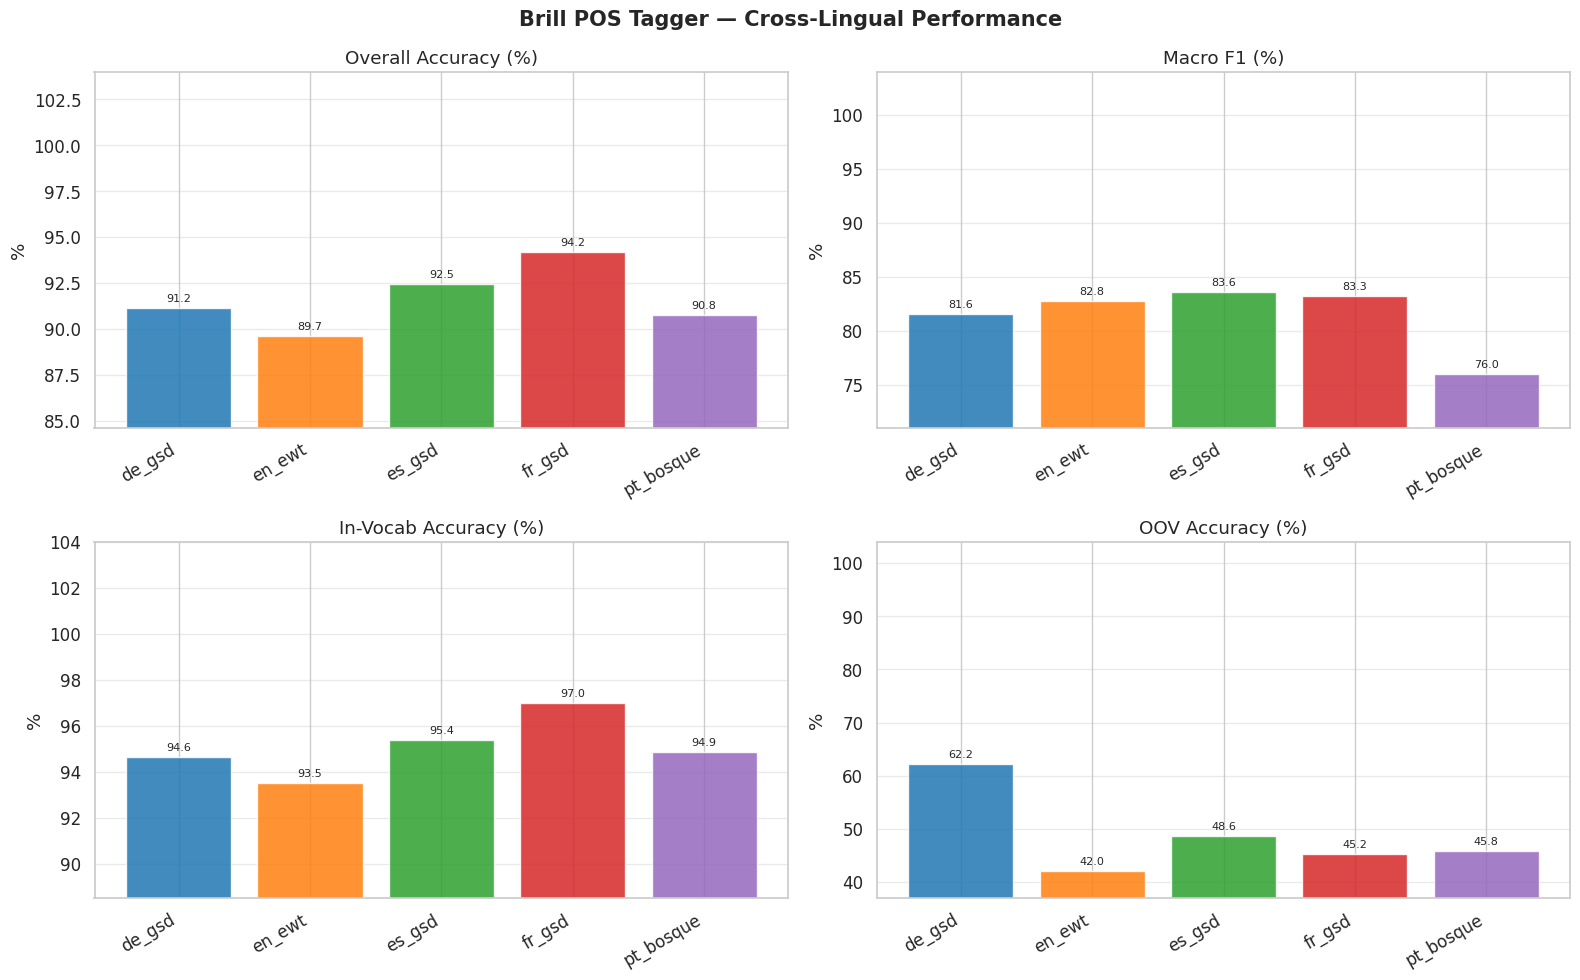

Saved -> ./pos_tagger_output/01_crosslingual_accuracy.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE   = sns.color_palette("tab10", len(TB_SORTED))
TB_COLORS = {tb: PALETTE[i] for i, tb in enumerate(TB_SORTED)}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Brill POS Tagger — Cross-Lingual Performance", fontsize=15, fontweight="bold")

metrics_4 = {
    "Overall Accuracy (%)": [eval_results[tb]["overall_acc"] * 100 for tb in TB_SORTED],
    "Macro F1 (%)": [eval_results[tb]["macro_f1"] * 100 for tb in TB_SORTED],
    "In-Vocab Accuracy (%)": [eval_results[tb]["iv_acc"] * 100 for tb in TB_SORTED],
    "OOV Accuracy (%)": [eval_results[tb]["oov_acc"] * 100 for tb in TB_SORTED],
}

for ax, (title, vals) in zip(axes.flat, metrics_4.items()):
    colors = [TB_COLORS[tb] for tb in TB_SORTED]
    bars = ax.bar(TB_SORTED, vals, color=colors, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("%")
    ax.set_ylim(max(0, min(vals) - 5), 104)
    ax.grid(axis="y", alpha=0.4)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
p1 = os.path.join(OUTPUT_DIR, "01_crosslingual_accuracy.png")
plt.savefig(p1, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p1}")

## 10 · Plots — Per-Tag F1 Heatmap

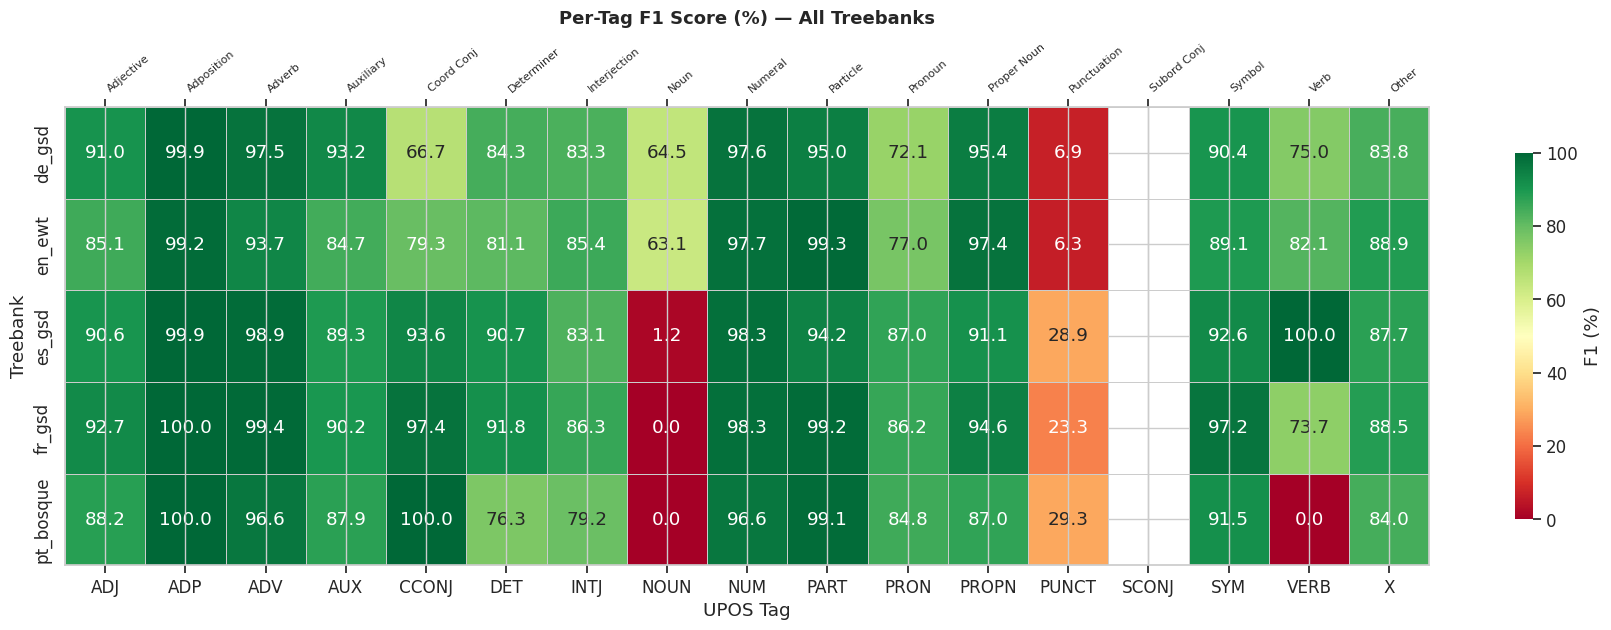

Saved -> ./pos_tagger_output/02_pertag_f1_heatmap.png


In [32]:
f1_matrix = pd.DataFrame(index=TB_SORTED, columns=UPOS_TAGS, dtype=float)
for tb in TB_SORTED:
    for tag in UPOS_TAGS:
        f1_matrix.loc[tb, tag] = eval_results[tb]["per_tag_f1"].get(tag, np.nan)

fig, ax = plt.subplots(figsize=(18, max(4, len(TB_SORTED) * 0.9 + 2)))
sns.heatmap(
    f1_matrix.astype(float) * 100, ax=ax,
    annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=0, vmax=100, linewidths=0.5, linecolor="#cccccc",
    cbar_kws={"label": "F1 (%)", "shrink": 0.8},
    mask=f1_matrix.isna(),
)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([i + 0.5 for i in range(len(UPOS_TAGS))])
ax2.set_xticklabels(
    [UPOS_DESCRIPTIONS.get(t, t) for t in UPOS_TAGS],
    rotation=40, ha="left", fontsize=8
)
ax.set_title("Per-Tag F1 Score (%) — All Treebanks", fontsize=13, fontweight="bold", pad=60)
ax.set_xlabel("UPOS Tag"); ax.set_ylabel("Treebank")
plt.tight_layout()
p2 = os.path.join(OUTPUT_DIR, "02_pertag_f1_heatmap.png")
plt.savefig(p2, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p2}")

## 11 · Plots — Confusion Matrices

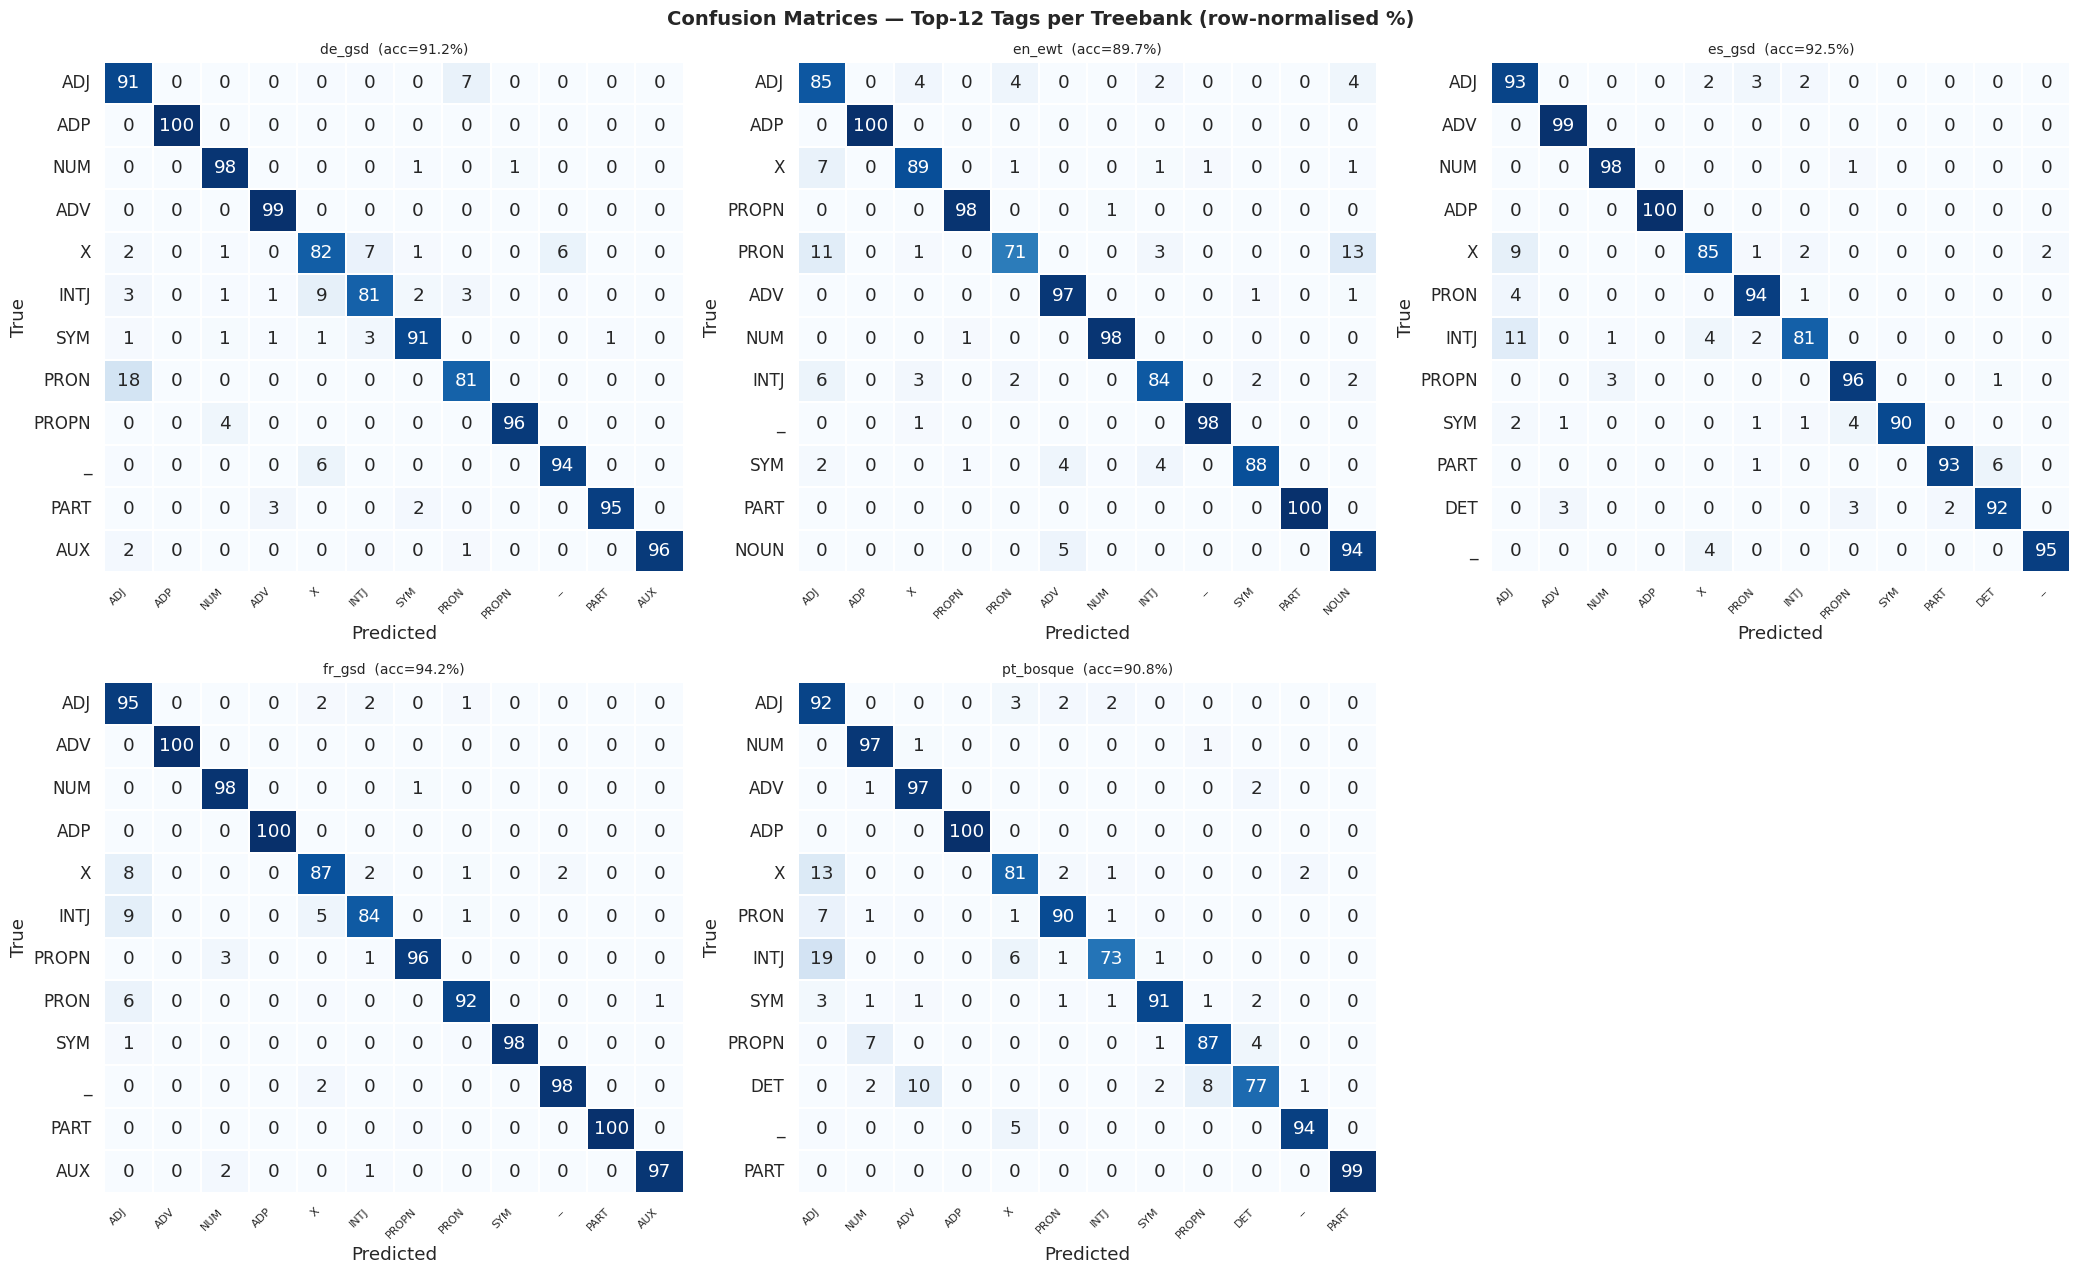

Saved -> ./pos_tagger_output/03_confusion_matrices.png


In [33]:
n_tb  = len(TB_SORTED)
ncols = min(3, n_tb)
nrows = (n_tb + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6.5 * nrows))
axes_flat = np.array(axes).flatten() if n_tb > 1 else [axes]
fig.suptitle("Confusion Matrices — Top-12 Tags per Treebank (row-normalised %)",
             fontsize=14, fontweight="bold")

for ax, tb in zip(axes_flat, TB_SORTED):
    e    = eval_results[tb]
    cm   = e["confusion_mat"].astype(float)
    tags = e["top_tags"]
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.divide(cm, row_sums, where=row_sums > 0) * 100
    sns.heatmap(
        cm_norm, ax=ax, xticklabels=tags, yticklabels=tags,
        annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
        linewidths=0.3, cbar=False,
    )
    ax.set_title(f"{tb}  (acc={e['overall_acc']*100:.1f}%)", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

for ax in axes_flat[n_tb:]:
    ax.set_visible(False)

plt.tight_layout()
p3 = os.path.join(OUTPUT_DIR, "03_confusion_matrices.png")
plt.savefig(p3, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p3}")

## 12 · Plots — OOV Analysis

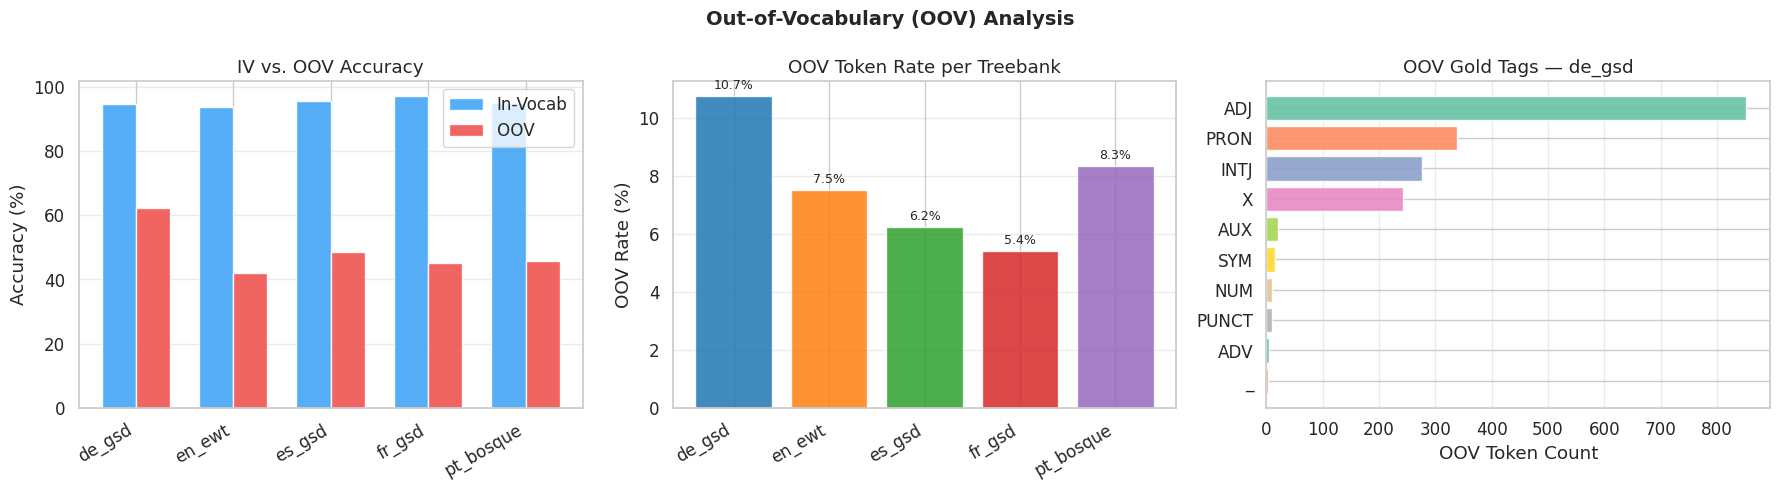

Saved -> ./pos_tagger_output/04_oov_analysis.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Out-of-Vocabulary (OOV) Analysis", fontsize=14, fontweight="bold")

x_tb  = np.arange(len(TB_SORTED))
width = 0.35

# IV vs OOV accuracy
ax = axes[0]
iv_acc  = [eval_results[tb]["iv_acc"]  * 100 for tb in TB_SORTED]
oov_acc = [eval_results[tb]["oov_acc"] * 100 for tb in TB_SORTED]
ax.bar(x_tb - width/2, iv_acc,  width, label="In-Vocab",  color="#42A5F5", alpha=0.9)
ax.bar(x_tb + width/2, oov_acc, width, label="OOV",       color="#EF5350", alpha=0.9)
ax.set_xticks(x_tb); ax.set_xticklabels(TB_SORTED, rotation=30, ha="right")
ax.set_ylabel("Accuracy (%)"); ax.set_title("IV vs. OOV Accuracy")
ax.legend(); ax.grid(axis="y", alpha=0.4)

# OOV rate
ax2 = axes[1]
oov_rates = [
    eval_results[tb]["oov_count"] /
    max(eval_results[tb]["oov_count"] + eval_results[tb]["iv_count"], 1) * 100
    for tb in TB_SORTED
]
bars = ax2.bar(TB_SORTED, oov_rates, color=[TB_COLORS[tb] for tb in TB_SORTED], alpha=0.85)
ax2.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax2.set_ylabel("OOV Rate (%)"); ax2.set_title("OOV Token Rate per Treebank")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
ax2.grid(axis="y", alpha=0.4)

# OOV tag distribution (first treebank)
ax3 = axes[2]
tb0 = TB_SORTED[0]
train_vocab0 = {tok.lower() for s in treebank_data[tb0]["train"] for tok, _ in s}
oov_tag_ctr  = Counter()
for s in treebank_data[tb0]["test"]:
    for tok, tag in s:
        if tok.lower() not in train_vocab0:
            oov_tag_ctr[tag] += 1
top_oov = oov_tag_ctr.most_common(10)
if top_oov:
    tg, cn = zip(*top_oov)
    ax3.barh(tg, cn, color=sns.color_palette("Set2", len(tg)), alpha=0.9)
    ax3.invert_yaxis()
    ax3.set_xlabel("OOV Token Count")
    ax3.set_title(f"OOV Gold Tags — {tb0}")
    ax3.grid(axis="x", alpha=0.4)

plt.tight_layout()
p4 = os.path.join(OUTPUT_DIR, "04_oov_analysis.png")
plt.savefig(p4, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p4}")

## 13 · Plots — Latency Benchmarks

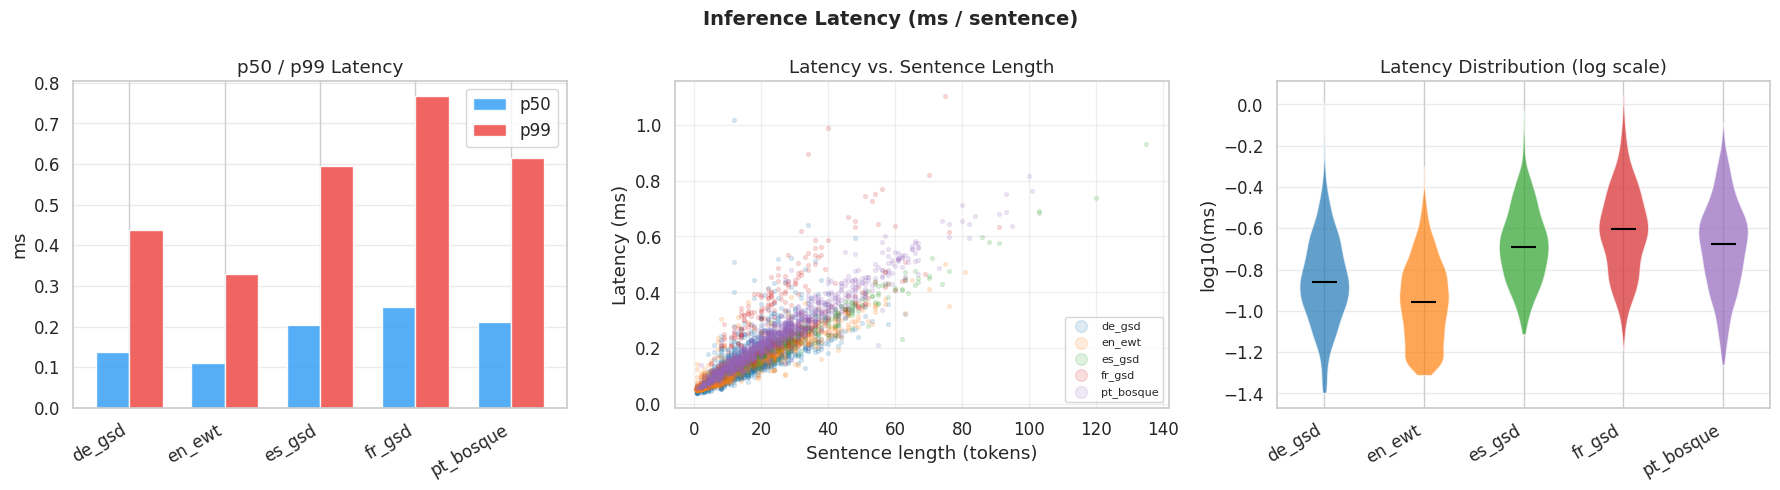

Saved -> ./pos_tagger_output/05_latency.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Inference Latency (ms / sentence)", fontsize=14, fontweight="bold")

# p50 / p99 bars
ax = axes[0]
p50s = [np.median(eval_results[tb]["lat_ms"])         for tb in TB_SORTED]
p99s = [np.percentile(eval_results[tb]["lat_ms"], 99) for tb in TB_SORTED]
ax.bar(x_tb - width/2, p50s, width, label="p50", color="#42A5F5", alpha=0.9)
ax.bar(x_tb + width/2, p99s, width, label="p99", color="#EF5350", alpha=0.9)
ax.set_xticks(x_tb); ax.set_xticklabels(TB_SORTED, rotation=30, ha="right")
ax.set_ylabel("ms"); ax.set_title("p50 / p99 Latency"); ax.legend(); ax.grid(axis="y", alpha=0.4)

# Latency vs. sentence length scatter
ax2 = axes[1]
for tb in TB_SORTED:
    lats = eval_results[tb]["lat_ms"]
    lens = [len(s) for s in treebank_data[tb]["test"]]
    mn   = min(len(lats), len(lens))
    ax2.scatter(lens[:mn], lats[:mn], alpha=0.15, s=8, color=TB_COLORS[tb], label=tb)
ax2.set_xlabel("Sentence length (tokens)")
ax2.set_ylabel("Latency (ms)")
ax2.set_title("Latency vs. Sentence Length")
ax2.legend(markerscale=3, fontsize=8); ax2.grid(alpha=0.3)

# Log-scale violin
ax3 = axes[2]
lat_data = [np.log10(eval_results[tb]["lat_ms"] + 1e-9) for tb in TB_SORTED]
vp = ax3.violinplot(lat_data, positions=range(len(TB_SORTED)), showmedians=True, showextrema=False)
for body, tb in zip(vp["bodies"], TB_SORTED):
    body.set_facecolor(TB_COLORS[tb]); body.set_alpha(0.7)
vp["cmedians"].set_color("black")
ax3.set_xticks(range(len(TB_SORTED)))
ax3.set_xticklabels(TB_SORTED, rotation=30, ha="right")
ax3.set_ylabel("log10(ms)")
ax3.set_title("Latency Distribution (log scale)")
ax3.grid(axis="y", alpha=0.4)

plt.tight_layout()
p5 = os.path.join(OUTPUT_DIR, "05_latency.png")
plt.savefig(p5, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p5}")

## 14 · Plots — Brill Rules Analysis

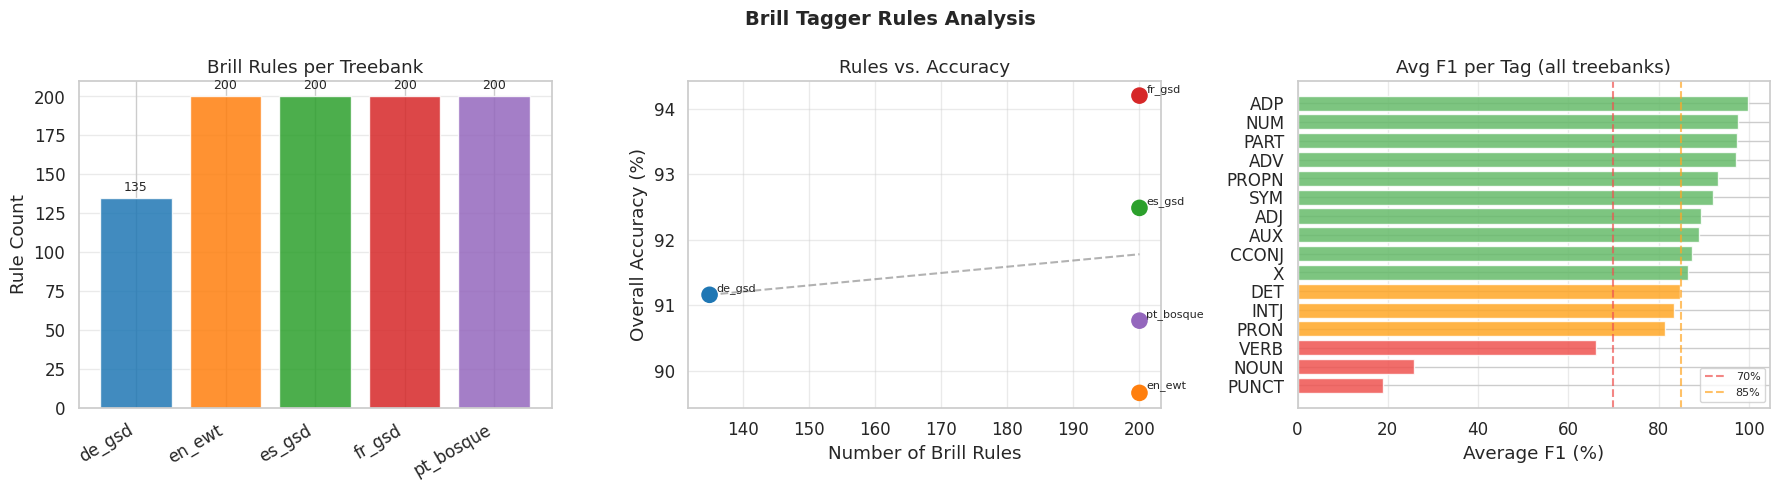

Saved -> ./pos_tagger_output/06_brill_rules_analysis.png


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Brill Tagger Rules Analysis", fontsize=14, fontweight="bold")

# Rules per treebank
ax = axes[0]
n_rules = [eval_results[tb]["n_rules"] for tb in TB_SORTED]
bars = ax.bar(TB_SORTED, n_rules, color=[TB_COLORS[tb] for tb in TB_SORTED], alpha=0.85)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
ax.set_ylabel("Rule Count"); ax.set_title("Brill Rules per Treebank")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.grid(axis="y", alpha=0.4)

# Rules vs. accuracy scatter
ax2 = axes[1]
accs = [eval_results[tb]["overall_acc"] * 100 for tb in TB_SORTED]
ax2.scatter(n_rules, accs, color=[TB_COLORS[tb] for tb in TB_SORTED], s=120, zorder=5)
for tb, nr, ac in zip(TB_SORTED, n_rules, accs):
    ax2.annotate(tb, (nr, ac), textcoords="offset points", xytext=(5, 3), fontsize=8)
if len(n_rules) > 2:
    z = np.polyfit(n_rules, accs, 1)
    xl = np.linspace(min(n_rules), max(n_rules), 100)
    ax2.plot(xl, np.poly1d(z)(xl), "--", color="gray", alpha=0.6, lw=1.5)
ax2.set_xlabel("Number of Brill Rules")
ax2.set_ylabel("Overall Accuracy (%)")
ax2.set_title("Rules vs. Accuracy")
ax2.grid(alpha=0.4)

# Average F1 per tag (sorted, coloured by difficulty)
ax3 = axes[2]
avg_f1_per_tag = {}
for tag in UPOS_TAGS:
    vals = [eval_results[tb]["per_tag_f1"].get(tag, np.nan) for tb in TB_SORTED]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        avg_f1_per_tag[tag] = np.mean(vals)
sorted_tags = sorted(avg_f1_per_tag, key=avg_f1_per_tag.get)
f1_vals     = [avg_f1_per_tag[t] * 100 for t in sorted_tags]
bar_cols    = ["#EF5350" if v < 70 else "#FFA726" if v < 85 else "#66BB6A" for v in f1_vals]
ax3.barh(sorted_tags, f1_vals, color=bar_cols, alpha=0.85)
ax3.axvline(70, color="#EF5350", lw=1.5, ls="--", alpha=0.7, label="70%")
ax3.axvline(85, color="#FFA726", lw=1.5, ls="--", alpha=0.7, label="85%")
ax3.set_xlabel("Average F1 (%)")
ax3.set_title("Avg F1 per Tag (all treebanks)")
ax3.legend(fontsize=8); ax3.grid(axis="x", alpha=0.4)

plt.tight_layout()
p6 = os.path.join(OUTPUT_DIR, "06_brill_rules_analysis.png")
plt.savefig(p6, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p6}")

## 15 · Plots — Per-Tag P/R/F1 Line Charts

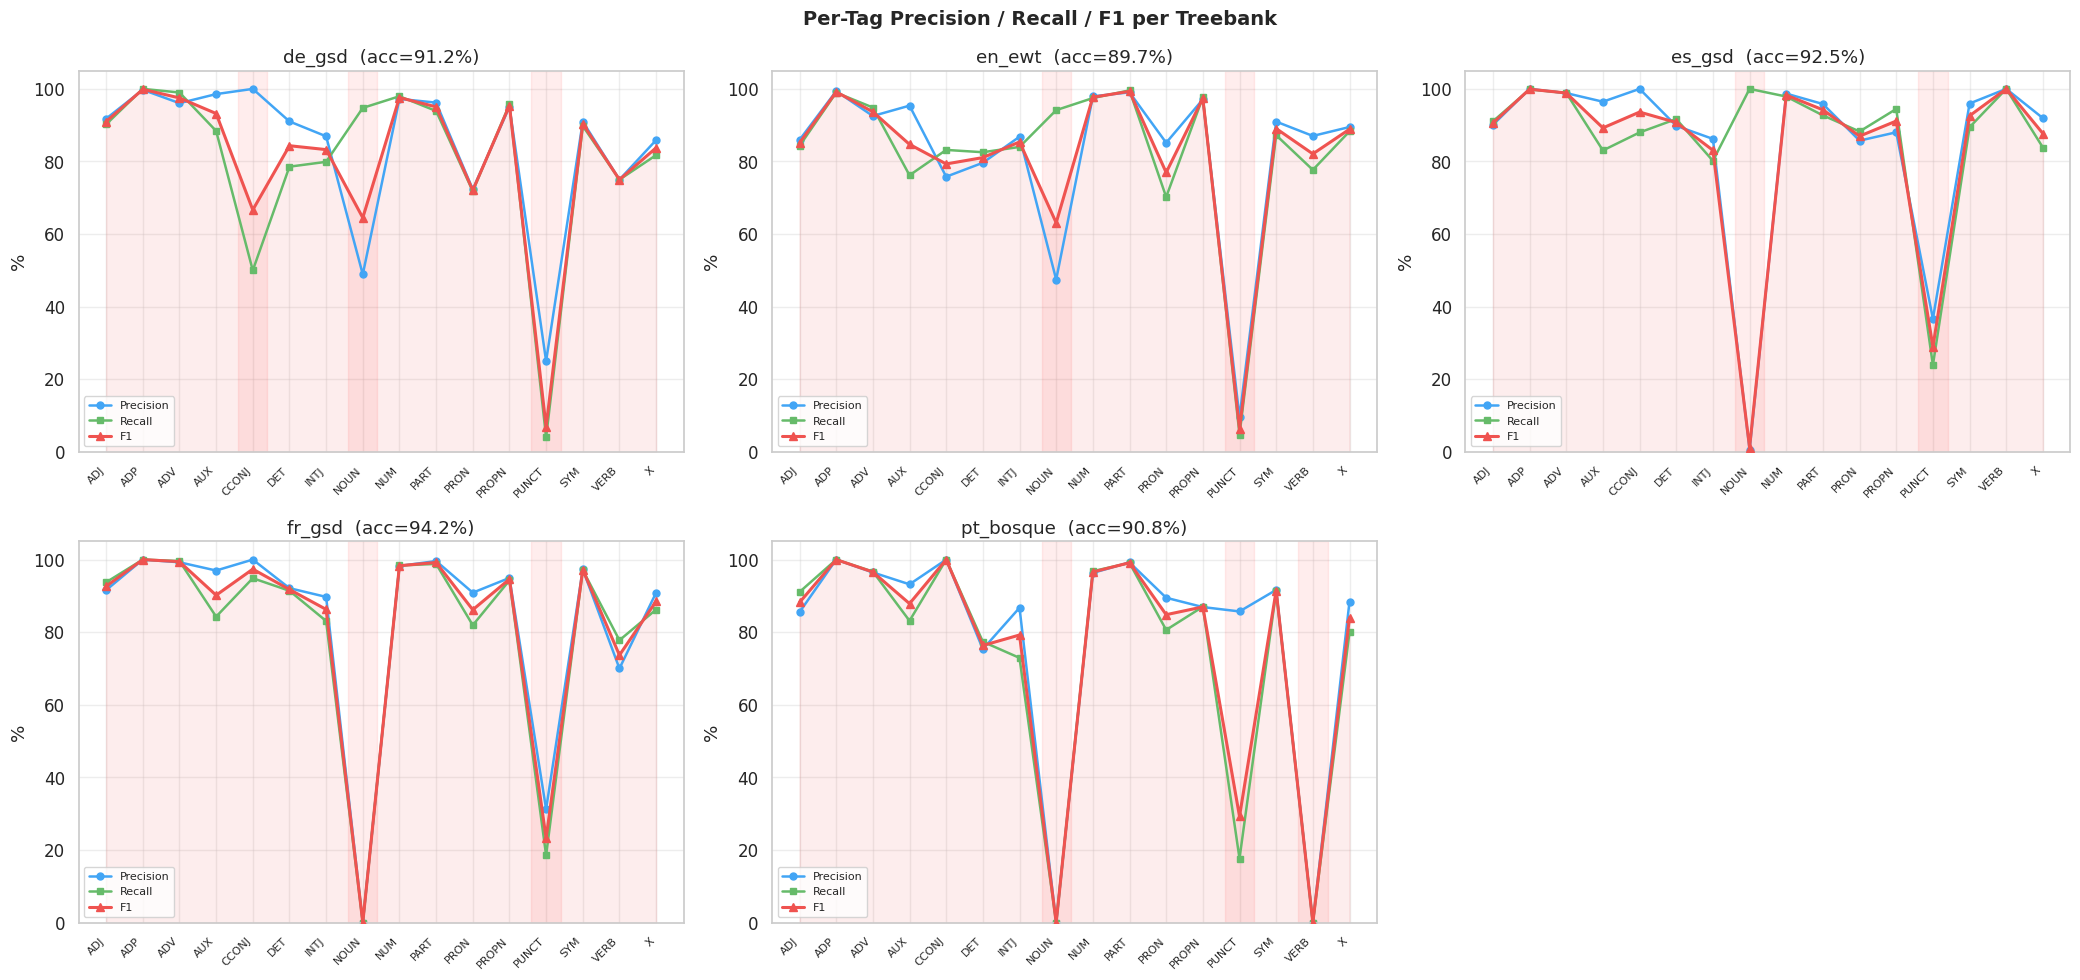

Saved -> ./pos_tagger_output/07_per_tag_prf.png


In [37]:
ncols = min(3, len(TB_SORTED))
nrows = (len(TB_SORTED) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes_flat = np.array(axes).flatten() if len(TB_SORTED) > 1 else [axes]
fig.suptitle("Per-Tag Precision / Recall / F1 per Treebank", fontsize=14, fontweight="bold")

for ax, tb in zip(axes_flat, TB_SORTED):
    e = eval_results[tb]
    tags_p = [t for t in UPOS_TAGS if t in e["per_tag_f1"]]
    xi = np.arange(len(tags_p))
    ax.plot(xi, [e["per_tag_prec"].get(t, 0)*100 for t in tags_p],
            "o-", color="#42A5F5", lw=1.8, ms=5, label="Precision")
    ax.plot(xi, [e["per_tag_rec"].get(t, 0)*100 for t in tags_p],
            "s-", color="#66BB6A", lw=1.8, ms=5, label="Recall")
    ax.plot(xi, [e["per_tag_f1"].get(t, 0)*100 for t in tags_p],
            "^-", color="#EF5350", lw=2.2, ms=6, label="F1", zorder=5)
    ax.fill_between(xi, [e["per_tag_f1"].get(t, 0)*100 for t in tags_p], alpha=0.1, color="#EF5350")
    ax.set_xticks(xi)
    ax.set_xticklabels(tags_p, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 105); ax.set_ylabel("%")
    ax.set_title(f"{tb}  (acc={e['overall_acc']*100:.1f}%)")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.35)
    for xi_i, f in enumerate([e["per_tag_f1"].get(t,0)*100 for t in tags_p]):
        if f < 70:
            ax.axvspan(xi_i - 0.4, xi_i + 0.4, alpha=0.07, color="red")

for ax in axes_flat[len(TB_SORTED):]:
    ax.set_visible(False)

plt.tight_layout()
p7 = os.path.join(OUTPUT_DIR, "07_per_tag_prf.png")
plt.savefig(p7, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p7}")

## 16 · Plots — Tag Distribution & Sentence Length

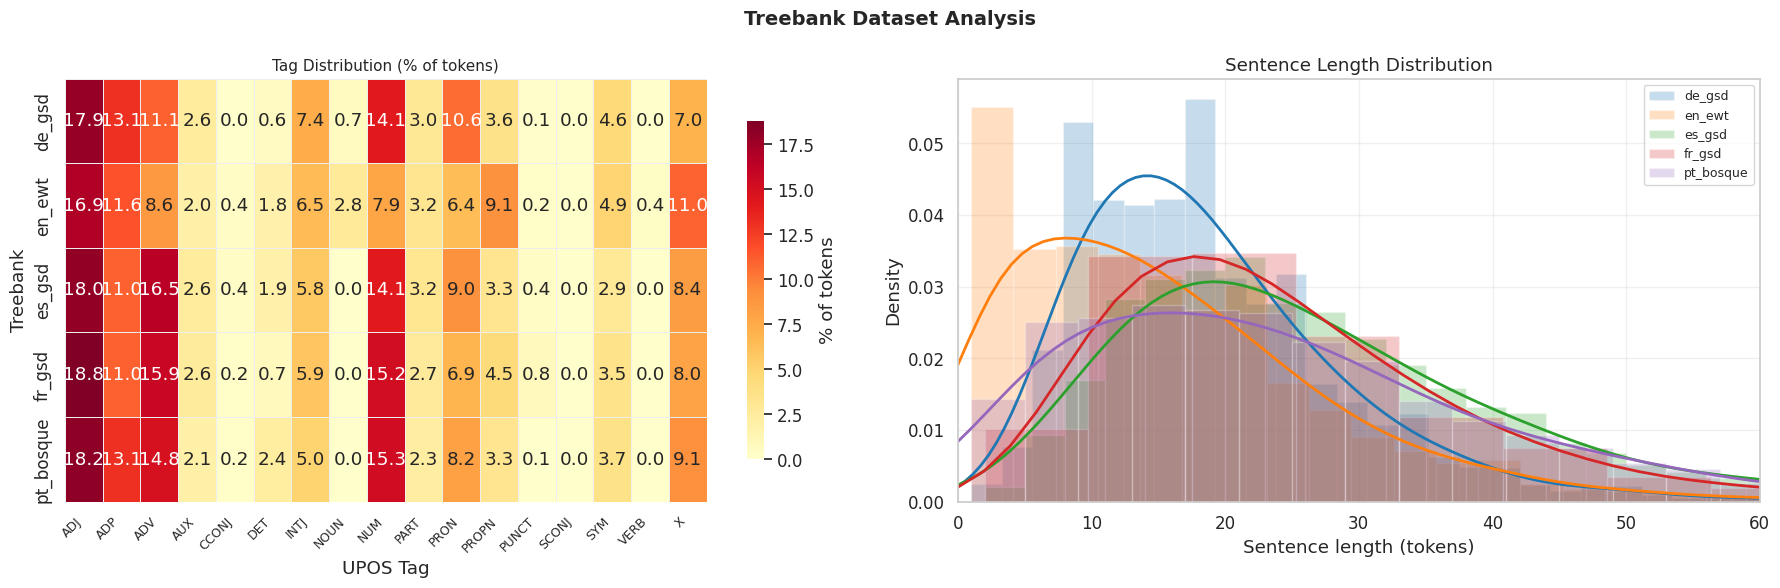

Saved -> ./pos_tagger_output/08_tag_and_length_dist.png


In [38]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Treebank Dataset Analysis", fontsize=14, fontweight="bold")

# UPOS distribution heatmap
ax = axes[0]
tag_dist_df = pd.DataFrame(index=TB_SORTED, columns=UPOS_TAGS, dtype=float)
for tb in TB_SORTED:
    td    = dataset_stats[tb]["tag_dist"]
    total = sum(td.values())
    for tag in UPOS_TAGS:
        tag_dist_df.loc[tb, tag] = td.get(tag, 0) / max(total, 1) * 100
sns.heatmap(
    tag_dist_df.astype(float), ax=ax, annot=True, fmt=".1f",
    cmap="YlOrRd", linewidths=0.5, linecolor="#eeeeee",
    cbar_kws={"label": "% of tokens", "shrink": 0.8},
)
ax.set_title("Tag Distribution (% of tokens)", fontsize=11)
ax.set_xlabel("UPOS Tag"); ax.set_ylabel("Treebank")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)

# Sentence length distribution
ax2 = axes[1]
for tb in TB_SORTED:
    lens = dataset_stats[tb]["sent_lens"]
    ax2.hist(lens, bins=50, density=True, alpha=0.25, color=TB_COLORS[tb], label=tb)
    if len(set(lens)) > 1:
        kde  = gaussian_kde(lens, bw_method=0.3)
        xkde = np.linspace(0, max(lens), 200)
        ax2.plot(xkde, kde(xkde), color=TB_COLORS[tb], lw=2)
ax2.set_xlabel("Sentence length (tokens)")
ax2.set_ylabel("Density")
ax2.set_title("Sentence Length Distribution")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_xlim(0, 60)

plt.tight_layout()
p8 = os.path.join(OUTPUT_DIR, "08_tag_and_length_dist.png")
plt.savefig(p8, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p8}")

## 18 · Plots — Learning Curves

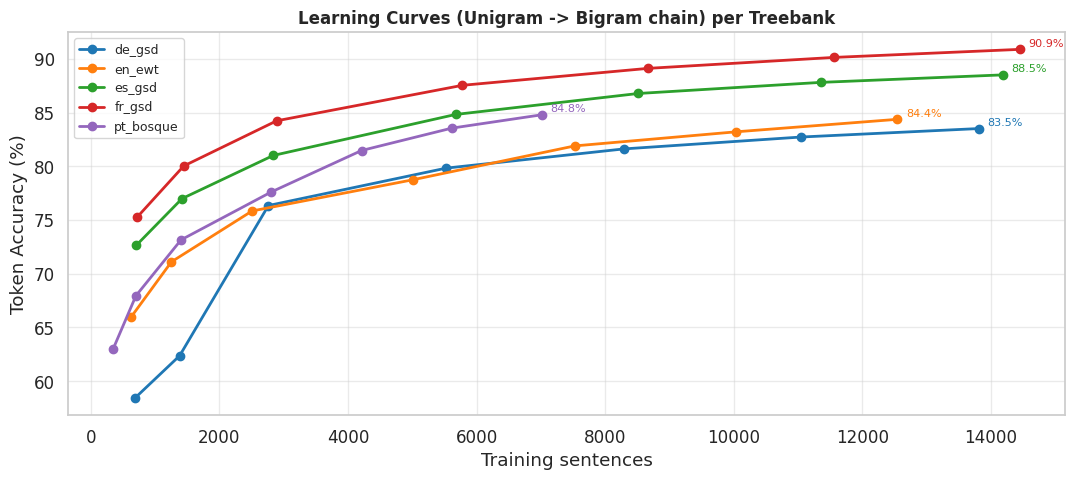

Saved -> ./pos_tagger_output/11_learning_curves.png


In [39]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("Learning Curves (Unigram -> Bigram chain) per Treebank",
             fontsize=12, fontweight="bold")

for tb in TB_SORTED:
    train_s = treebank_data[tb]["train"]
    test_s  = treebank_data[tb]["test"]
    accs, sizes = [], []
    for frac in LEARNING_CURVE_FRACS:
        n   = max(1, int(len(train_s) * frac))
        sub = train_s[:n]
        uni = UnigramTagger(sub, backoff=DefaultTagger("NOUN"))
        bi  = BigramTagger(sub, backoff=uni)
        accs.append(bi.accuracy(test_s) * 100)
        sizes.append(n)
    ax.plot(sizes, accs, "o-", color=TB_COLORS[tb], lw=2, label=tb, ms=6)
    # Annotate final value
    ax.annotate(f"{accs[-1]:.1f}%", (sizes[-1], accs[-1]),
                textcoords="offset points", xytext=(6, 2), fontsize=8,
                color=TB_COLORS[tb])

ax.set_xlabel("Training sentences")
ax.set_ylabel("Token Accuracy (%)")
ax.legend(fontsize=9); ax.grid(alpha=0.4)
plt.tight_layout()
p11 = os.path.join(OUTPUT_DIR, "11_learning_curves.png")
plt.savefig(p11, dpi=130, bbox_inches="tight"); plt.show()
print(f"Saved -> {p11}")

## 21 · MLflow Tracking

In [40]:
import mlflow

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

all_plots = [p1, p2, p3, p4, p5, p6, p7, p8, p11]

for tb in TB_SORTED:
    e  = eval_results[tb]
    ds = dataset_stats[tb]
    lat = e["lat_ms"]

    with mlflow.start_run(run_name=tb):
        mlflow.log_params({
            "treebank":       tb,
            "hf_repo":        HF_UD_REPO,
            "tag_set":        TAG_SET,
            "brill_max_rules":BRILL_MAX_RULES,
            "brill_min_score":BRILL_MIN_SCORE,
            "suffix_len":     SUFFIX_LEN,
            "lowercase":      LOWERCASE,
            "n_train":        ds["n_train"],
            "n_test":         ds["n_test"],
            "vocab_size":     ds["vocab_size"],
            "n_brill_rules":  e["n_rules"],
        })
        mlflow.log_metrics({
            "overall_acc":  e["overall_acc"],
            "macro_f1":     e["macro_f1"],
            "iv_acc":       e["iv_acc"],
            "oov_acc":      e["oov_acc"],
            "lat_p50_ms":   float(np.median(lat)),
            "lat_p99_ms":   float(np.percentile(lat, 99)),
            **{f"f1_{tag}": v for tag, v in e["per_tag_f1"].items()},
        })
        pkl = os.path.join(OUTPUT_DIR, f"{tb}_brill_pos.pkl")
        if os.path.exists(pkl):
            mlflow.log_artifact(pkl, artifact_path="models")
        for plot in all_plots:
            if plot and os.path.exists(plot):
                mlflow.log_artifact(plot, artifact_path="plots")

print("MLflow runs logged.")

MLflow runs logged.


## 22 · HuggingFace Upload (optional)

In [41]:
if HF_UPLOAD:
    if not HF_TOKEN or not HF_UPLOAD_REPO:
        print("Set HF_TOKEN and HF_UPLOAD_REPO to upload.")
    else:
        from huggingface_hub import HfApi
        api = HfApi(token=HF_TOKEN)
        api.create_repo(HF_UPLOAD_REPO, repo_type="model", exist_ok=True)
        for tb in TB_SORTED:
            f = os.path.join(OUTPUT_DIR, f"{tb}_brill_pos.pkl")
            if os.path.exists(f):
                api.upload_file(path_or_fileobj=f,
                    path_in_repo=f"models/{os.path.basename(f)}",
                    repo_id=HF_UPLOAD_REPO, repo_type="model")
        for plot in all_plots:
            if plot and os.path.exists(plot):
                api.upload_file(path_or_fileobj=plot,
                    path_in_repo=f"plots/{os.path.basename(plot)}",
                    repo_id=HF_UPLOAD_REPO, repo_type="model")
        print(f"Uploaded -> https://huggingface.co/{HF_UPLOAD_REPO}")
else:
    print("HF_UPLOAD=False — skipping.")

HF_UPLOAD=False — skipping.
